Setup, W&B & Load Mall Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import wandb

# Inisialisasi W&B
run = wandb.init(project="customer-segmentation", name="kmeans-pca-baseline")

# Tautan Dataset yang Lebih Stabil
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)

# Kita hanya gunakan fitur Annual Income dan Spending Score untuk latihan awal
X = df.iloc[:, [3, 4]].values

print(f"Dataset Berhasil Dimuat! Shape: {df.shape}")
df.head()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mushab-a-fathin (mushab-a-fathin-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset Berhasil Dimuat! Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Mencari K Optimal (Elbow Method)

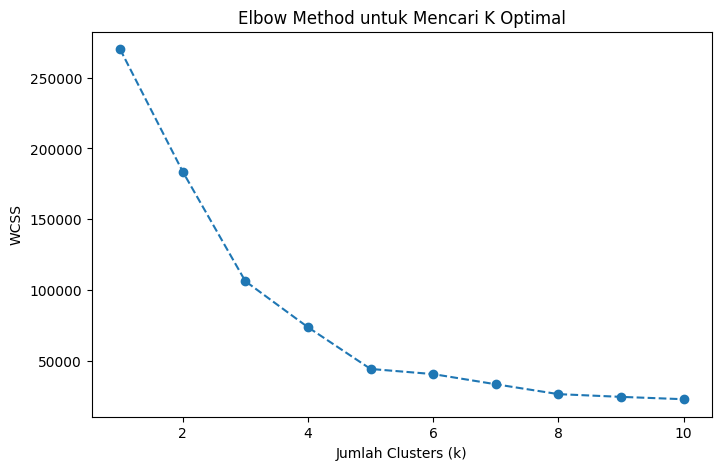

In [2]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

fig1 = plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method untuk Mencari K Optimal')
plt.xlabel('Jumlah Clusters (k)')
plt.ylabel('WCSS')

# Log WCSS ke W&B untuk melihat "siku" grafik
wandb.log({"WCSS_Curve": wandb.Image(fig1)})
plt.show()
plt.close(fig1)

Training K-Means & Visualisasi Cluster

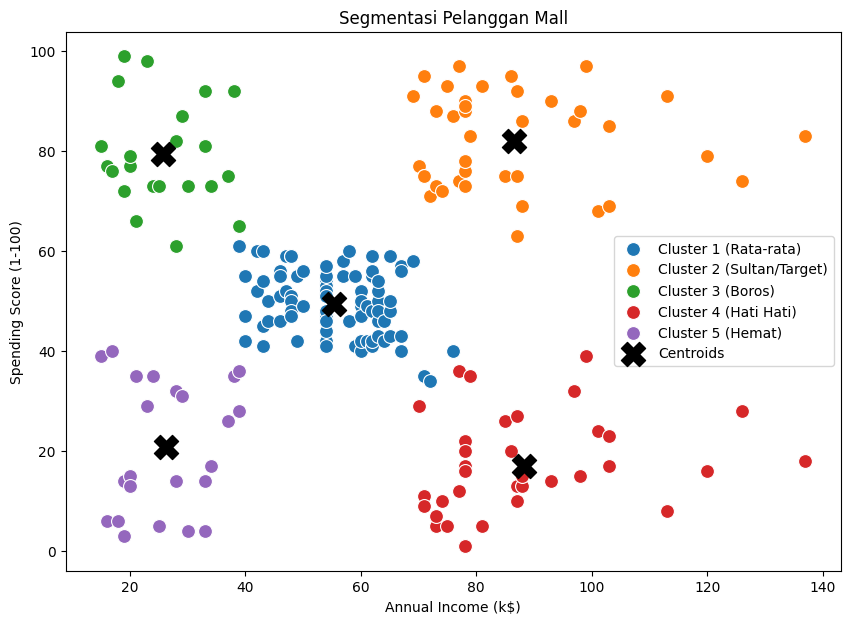

In [3]:
# Berdasarkan Elbow, k=5 biasanya optimal untuk dataset ini
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Visualisasi Kelompok Pelanggan
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[y_kmeans == 0, 0], y=X[y_kmeans == 0, 1], s=100, label='Cluster 1 (Rata-rata)')
sns.scatterplot(x=X[y_kmeans == 1, 0], y=X[y_kmeans == 1, 1], s=100, label='Cluster 2 (Sultan/Target)')
sns.scatterplot(x=X[y_kmeans == 2, 0], y=X[y_kmeans == 2, 1], s=100, label='Cluster 3 (Boros)')
sns.scatterplot(x=X[y_kmeans == 3, 0], y=X[y_kmeans == 3, 1], s=100, label='Cluster 4 (Hati Hati)')
sns.scatterplot(x=X[y_kmeans == 4, 0], y=X[y_kmeans == 4, 1], s=100, label='Cluster 5 (Hemat)')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='black', label='Centroids', marker='X')
plt.title('Segmentasi Pelanggan Mall')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Menggunakan PCA untuk Visualisasi Multidimensi

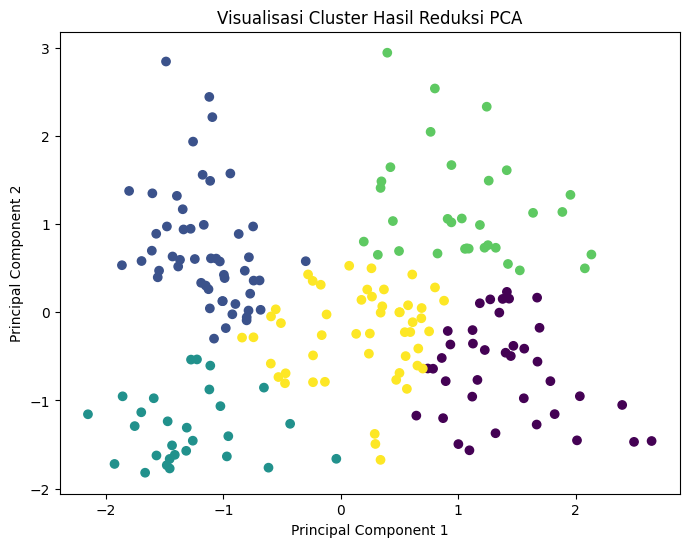

In [4]:
# Sekarang kita gunakan semua fitur (Age, Income, Spending)
X_full = df.iloc[:, [2, 3, 4]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Reduksi dari 3D menjadi 2D agar bisa digambar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_full = KMeans(n_clusters=5, random_state=42)
clusters_full = kmeans_full.fit_predict(X_pca)

fig2 = plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_full, cmap='viridis')
plt.title('Visualisasi Cluster Hasil Reduksi PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

wandb.log({"PCA_Cluster_Scatter": wandb.Image(fig2)})
plt.show()
plt.close(fig2)

wandb.finish()